In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('./data/resale_transactions.csv')

display(df.head())
display(df.info())
display(df.isnull().sum())

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  object 
 2   flat_type            88688 non-null  object 
 3   block                88688 non-null  object 
 4   street_name          88688 non-null  object 
 5   storey_range         88688 non-null  object 
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  object 
 9   resale_price         88688 non-null  float64
 10  town_id              88688 non-null  int64  
 11  flatm_id             88688 non-null  int64  
 12  town_name            87905 non-null  object 
 13  flatm_name           88174 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 9.5+ MB


None

id                       0
month                    0
flat_type                0
block                    0
street_name              0
storey_range             0
floor_area_sqm           0
lease_commence_date      0
remaining_lease          0
resale_price             0
town_id                  0
flatm_id                 0
town_name              783
flatm_name             514
dtype: int64

In [2]:
display(df.describe().T)
display(df.duplicated().sum())
display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

,count,mean,std,min,25%,50%,75%,max
id,88688.0,42233.303739,24376.312037,1.0,21136.75,42228.5,63339.25,84465.0
floor_area_sqm,88688.0,97.520444,24.197379,31.0,76.00,96.0,112.00,280.0
lease_commence_date,88688.0,1570.225352,1226.315949,-2016.0,1980.00,1988.0,2000.00,2016.0
resale_price,88688.0,438679.303299,146670.254508,160000.0,335000.00,408000.0,505000.00,1200000.0
town_id,88688.0,14.631337,8.032285,1.0,8.00,15.0,22.00,26.0
flatm_id,88688.0,8.889185,3.906898,1.0,5.00,8.0,12.00,21.0


4223

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
103,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
88570,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
106,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
88156,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
114,115,2017-03,4 ROOM,274D,PUNGGOL PL,16 TO 18,93.0,2013,95 years 04 months,560000.0,18,13,PUNGGOL,Premium Apartment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87372,84427,2019-01,5 ROOM,348D,YISHUN AVE 11,13 TO 15,112.0,2013,93 years 09 months,758000.0,26,4,YISHUN,DBSS
84428,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
85835,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
84461,84462,2015-06,5 ROOM,596A,ANG MO KIO ST 52,07 TO 09,110.0,2002,86,760000.0,1,5,ANG MO KIO,Improved


4 ROOM              34741
3 ROOM              22557
5 ROOM              21484
EXECUTIVE            7017
FOUR ROOM            1824
2 ROOM                991
1 ROOM                 39
MULTI-GENERATION       35
Name: flat_type, dtype: int64


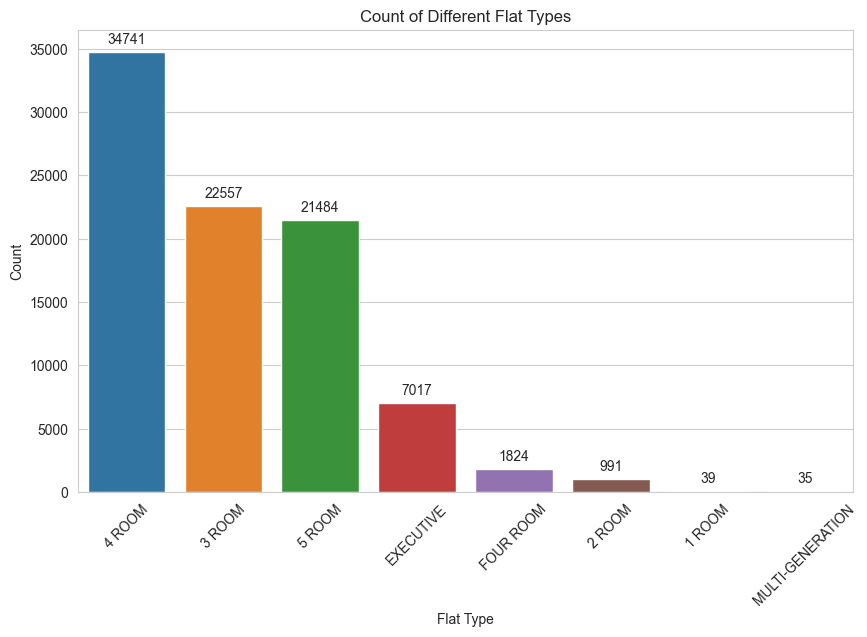

In [3]:
# Verify the changes
print(df['flat_type'].value_counts())

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='flat_type', order=df['flat_type'].value_counts().index, data=df)
plt.title('Count of Different Flat Types')
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')
plt.show()

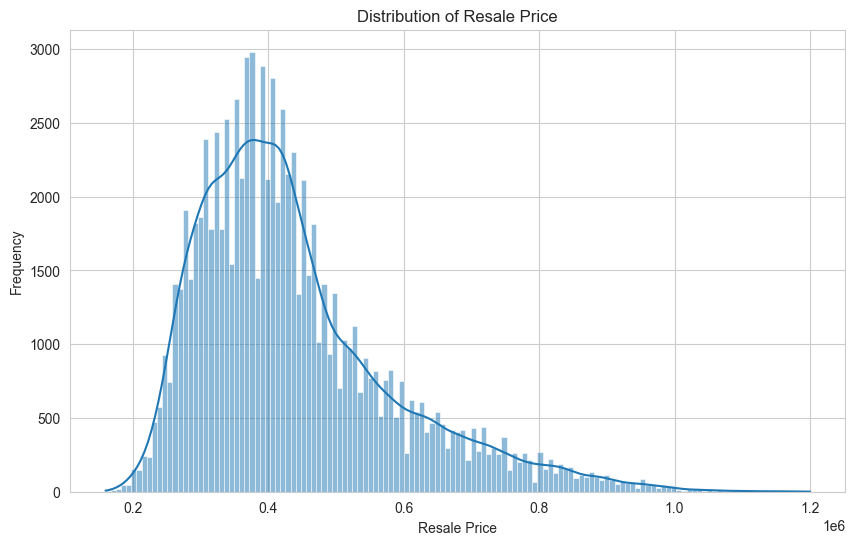

In [4]:
# Histogram for resale price
plt.figure(figsize=(10, 6))
sns.histplot(df['resale_price'], kde=True) # type: ignore
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price')
plt.ylabel('Frequency')
plt.show()

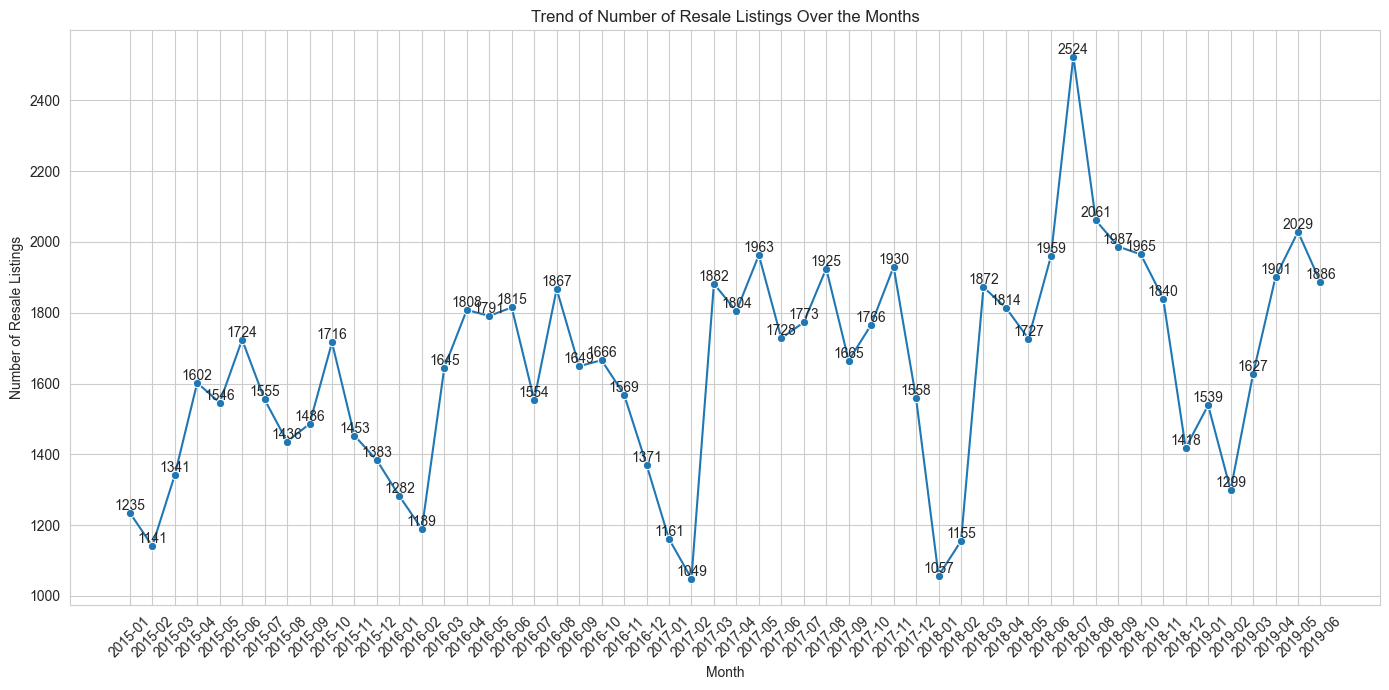

In [5]:
# Count the Number of Listings by Month
month_counts = df['month'].value_counts().sort_index()

# Create the Line Chart
plt.figure(figsize=(14, 7))
line_plot = sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o')

# Annotate the Data Points
for x, y in zip(month_counts.index, month_counts.values):
    plt.text(x, y, f'{y}', ha='center', va='bottom')

# Label the Chart
plt.title('Trend of Number of Resale Listings Over the Months')
plt.xlabel('Month')
plt.ylabel('Number of Resale Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


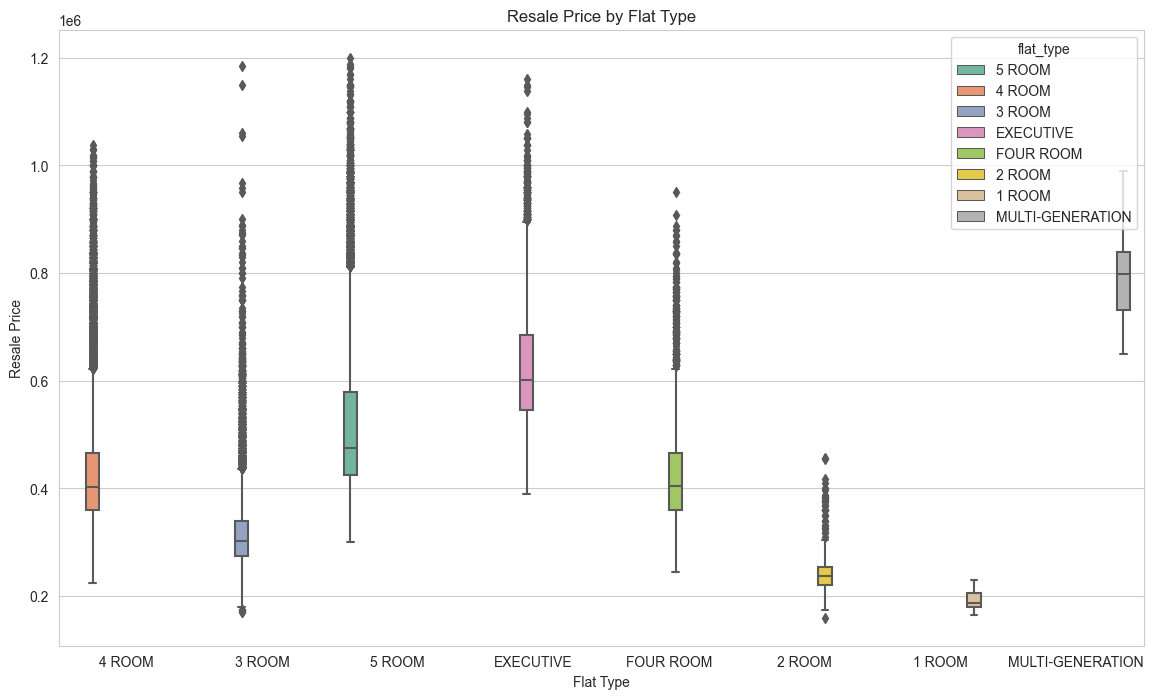

In [6]:
# Box plot for flat_type vs resale_price
plt.figure(figsize=(14, 8))
sns.boxplot(x='flat_type', y='resale_price', order=df['flat_type'].value_counts().index, data=df, hue='flat_type', palette='Set2')
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price')
plt.xticks(rotation=0)
plt.show()

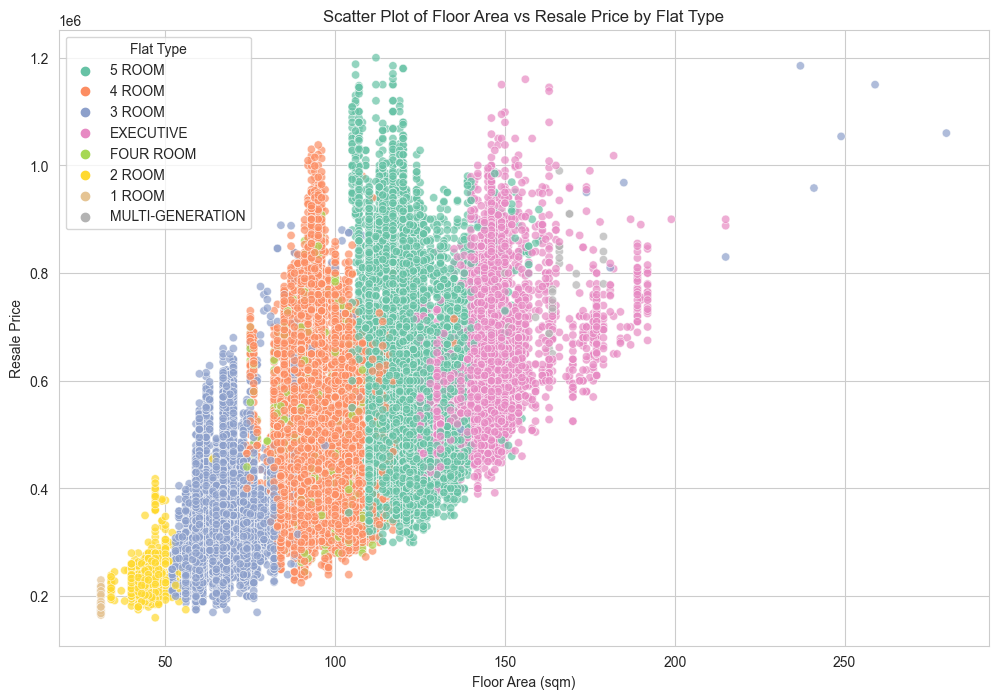

In [7]:
# Scatter plot for floor area vs resale price with color encoding for flat type
plt.figure(figsize=(12, 8))
sns.scatterplot(x='floor_area_sqm', y='resale_price', hue='flat_type', data=df, palette='Set2', alpha=0.7)
plt.title('Scatter Plot of Floor Area vs Resale Price by Flat Type')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price')
plt.legend(title='Flat Type')
plt.show()

In [8]:
# Filter the data for outliers
outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['floor_area_sqm'] > 150) & 
                        (df['resale_price'] > 800000)]

# Display the outliers
print(outliers)

# Further filter the data for 3-room terrace flats
terrace_outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['flatm_name'] == "Terrace")]

# Display the outliers
terrace_outliers.describe().T

          id    month flat_type block  street_name storey_range  \
856      857  2018-09    3 ROOM    41  JLN BAHAGIA     01 TO 03   
7472    7473  2018-06    3 ROOM    58   JLN MA'MOR     01 TO 03   
31858  31859  2015-03    3 ROOM    53   JLN MA'MOR     01 TO 03   
47739  47740  2017-12    3 ROOM    65   JLN MA'MOR     01 TO 03   
51992  51993  2018-05    3 ROOM    44  JLN BAHAGIA     01 TO 03   
54578  54579  2016-12    3 ROOM    57   JLN MA'MOR     01 TO 03   
61997  61998  2017-05    3 ROOM    59   JLN MA'MOR     01 TO 03   
66428  66429  2017-06    3 ROOM    38  JLN BAHAGIA     01 TO 03   
78787  78788  2015-06    3 ROOM    60  JLN BAHAGIA     01 TO 03   

       floor_area_sqm  lease_commence_date     remaining_lease  resale_price  \
856             237.0                 1972  52 years 10 months     1185000.0   
7472            174.0                 1972  53 years 02 months      950000.0   
31858           280.0                 1972                  56     1060000.0   
47739    

,count,mean,std,min,25%,50%,75%,max
id,50.0,48500.9800,22477.599512,857.0,32164.0,51140.5,66203.50,83890.0
floor_area_sqm,50.0,116.7400,54.709925,78.0,83.0,93.0,111.75,280.0
lease_commence_date,50.0,1892.4800,557.675432,-1972.0,1972.0,1972.0,1972.00,1972.0
resale_price,50.0,815704.8176,120827.585914,635000.0,731250.0,800000.0,873750.00,1185000.0
town_id,50.0,15.6400,1.481312,15.0,15.0,15.0,15.00,19.0
flatm_id,50.0,19.0000,0.000000,19.0,19.0,19.0,19.00,19.0


In [9]:
# Absolute negative years values
df['lease_commence_date'] = df['lease_commence_date'].abs()

# Replace 'FOUR ROOM' with '4 ROOM' in the 'flat_type' column
df['flat_type'] = df['flat_type'].replace('FOUR ROOM', '4 ROOM')

def fill_missing_names(df: pd.DataFrame, id_column: str, name_column: str) -> pd.DataFrame:
    """
    Fills missing values in the 'name_column' using the 'id_column'. 

    Args:
        df (pd.DataFrame): The DataFrame containing the columns to be filled. 
        id_column (str): The name of the column containing the IDs.
        name_column (str): The name of the column  containing the names to be filled.

    Returns: 
        pd.DataFrame: The DataFrame with missing values in 'name_column' filled. 

    """

    # Identify missing values in the 'name_column' 
    missing_names = df[name_column].isna()
    print(missing_names)

    # Create a dictionary mapping 'id_column' to 'name_column' 
    name_mapping = df[[id_column, name_column]].dropna().drop_duplicates().set_index(id_column)[name_column].to_dict()
    print(name_mapping)

    # Fill missing 'name_column' using the mapping
    df.loc[missing_names, name_column] = df.loc[missing_names, id_column].map(name_mapping)

    return df

# Fill missing values in 'town_name' column
df = fill_missing_names(df=df, id_column='town_id', name_column='town_name')

# Fill missing values in 'flatm_name' column
df = fill_missing_names(df=df, id_column='flatm_id', name_column='flatm_name')

0        False
1        False
2        False
3        False
4        False
         ...  
88683    False
88684    False
88685    False
88686    False
88687    False
Name: town_name, Length: 88688, dtype: bool
{17: 'PASIR RIS', 21: 'SENGKANG', 9: 'CHOA CHU KANG', 12: 'HOUGANG', 22: 'SERANGOON', 1: 'ANG MO KIO', 3: 'BISHAN', 2: 'BEDOK', 15: 'KALLANG/WHAMPOA', 14: 'JURONG WEST', 4: 'BUKIT BATOK', 19: 'QUEENSTOWN', 26: 'YISHUN', 13: 'JURONG EAST', 18: 'PUNGGOL', 6: 'BUKIT PANJANG', 25: 'WOODLANDS', 24: 'TOA PAYOH', 20: 'SEMBAWANG', 10: 'CLEMENTI', 11: 'GEYLANG', 5: 'BUKIT MERAH', 23: 'TAMPINES', 8: 'CENTRAL AREA', 16: 'MARINE PARADE', 7: 'BUKIT TIMAH'}
0        False
1        False
2        False
3        False
4        False
         ...  
88683    False
88684    False
88685    False
88686    False
88687    False
Name: flatm_name, Length: 88688, dtype: bool
{5: 'Improved', 8: 'Model A', 12: 'New Generation', 13: 'Premium Apartment', 17: 'Simplified', 18: 'Standard', 7: 'Maisonette', 3: 'A

In [10]:
# Drop irrelevant features
df = df.drop(columns=['id', 'town_id', 'flatm_id'])

# Convert 'month' column to datetime
df['year_month'] = pd.to_datetime(df['month'], format='%Y-%m') 

# Extract year and month from the datetime object
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

df.head()

# drop year_month
df = df.drop(columns=['year_month'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                88688 non-null  int64  
 1   flat_type            88688 non-null  object 
 2   block                88688 non-null  object 
 3   street_name          88688 non-null  object 
 4   storey_range         88688 non-null  object 
 5   floor_area_sqm       88688 non-null  float64
 6   lease_commence_date  88688 non-null  int64  
 7   remaining_lease      88688 non-null  object 
 8   resale_price         88688 non-null  float64
 9   town_name            88688 non-null  object 
 10  flatm_name           88688 non-null  object 
 11  year                 88688 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 8.1+ MB
None


In [11]:
import re

def extract_lease_info(lease_str: str) -> int:
    """
    Convert lease information from a string format to total months.

    This function takes a string representing the remaining lease period, which
    may include years and months in various formats (e.g., "70 years 3 months",
    "85 years", "67"), and converts it to the total number of months.

    Args:
        lease_str (str): The remaining lease period as a string.

    Returns:
        int: The total number of months, or None if the input is NaN.
    """

    if pd.isna(lease_str):
        return None # type: ignore
    
    # Regular expression to extract years and months
    years_match = re.search(r'(\d+)\s*years?', lease_str)
    months_match = re.search(r'(\d+)\s*months?', lease_str)
    number_match = re.match(r'^\d+$', lease_str.strip())
    
    if years_match:
        years = int(years_match.group(1))
    elif number_match:  # If only a number is present, assume it's in years
        years = int(number_match.group(0))
    else:
        years = 0
        
    months = int(months_match.group(1)) if months_match else 0
    
    # Convert the total lease period to months
    total_months = years * 12 + months
    return total_months

# Extract lease information
df['remaining_lease_months'] = df['remaining_lease'].apply(extract_lease_info) 
# Display a random sample of the data to check the transformation
df[['remaining_lease', 'remaining_lease_months']].sample(5)


# Drop the 'remaining_lease' column
df = df.drop(columns=['remaining_lease']) 

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month                   88688 non-null  int64  
 1   flat_type               88688 non-null  object 
 2   block                   88688 non-null  object 
 3   street_name             88688 non-null  object 
 4   storey_range            88688 non-null  object 
 5   floor_area_sqm          88688 non-null  float64
 6   lease_commence_date     88688 non-null  int64  
 7   resale_price            88688 non-null  float64
 8   town_name               88688 non-null  object 
 9   flatm_name              88688 non-null  object 
 10  year                    88688 non-null  int64  
 11  remaining_lease_months  88688 non-null  int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 8.1+ MB
None


In [12]:
# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    """
    Converts a storey range string into its average numerical value.
    
    The function takes a storey range in the format 'XX TO YY', splits it into two parts,
    converts these parts to integers, and returns the average of these integers.
    
    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.
        
    Returns:
        float: The average value of the two storeys in the range.
        
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month                   88688 non-null  int64  
 1   flat_type               88688 non-null  object 
 2   block                   88688 non-null  object 
 3   street_name             88688 non-null  object 
 4   storey_range            88688 non-null  float64
 5   floor_area_sqm          88688 non-null  float64
 6   lease_commence_date     88688 non-null  int64  
 7   resale_price            88688 non-null  float64
 8   town_name               88688 non-null  object 
 9   flatm_name              88688 non-null  object 
 10  year                    88688 non-null  int64  
 11  remaining_lease_months  88688 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 8.1+ MB
None


In [13]:
# Drop the 'block' and 'street_name' columns
df = df.drop(columns=['block', 'street_name'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month                   88688 non-null  int64  
 1   flat_type               88688 non-null  object 
 2   storey_range            88688 non-null  float64
 3   floor_area_sqm          88688 non-null  float64
 4   lease_commence_date     88688 non-null  int64  
 5   resale_price            88688 non-null  float64
 6   town_name               88688 non-null  object 
 7   flatm_name              88688 non-null  object 
 8   year                    88688 non-null  int64  
 9   remaining_lease_months  88688 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 6.8+ MB
None


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define numerical features to be standardized
numerical_features = ['floor_area_sqm', 'remaining_lease_months', 'lease_commence_date', 'year']

# Create a numerical transformer pipeline
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define nominal features to be one-hot encoded
nominal_features = ['month', 'town_name', 'flatm_name']

# Create a nominal transformer pipeline. 
nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Define ordinal features to be ordinally encoded.
ordinal_features = ['flat_type']

# Define the ordinal categories for flat_type. 
flat_type_categories = ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 
                        'MULTI-GENERATION', 'EXECUTIVE']

# Create an ordinal transformer pipeline
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[flat_type_categories],
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

# Define passthrough features that will not be transformed. 
passthrough_features = ['storey_range']


In [16]:
from sklearn.compose import ColumnTransformer

# Combine transformers into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('pass', 'passthrough', passthrough_features) # Pass through storey_range as a numeric feature.
    ],
    remainder='drop',
    n_jobs=1
)

preprocessor # type: ignore

ColumnTransformer(n_jobs=1,
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['floor_area_sqm', 'remaining_lease_months',
                                  'lease_commence_date', 'year']),
                                ('nom',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['month', 'town_name', 'flatm_name']),
                                ('ord',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder(categories=[['1 '
                                                                              'ROOM',
                                                                              '2 '
                                                                              'ROOM',
                                                                              '3 '
                                                                              'ROOM',
                                                                              '4 '
                                                                              'ROOM',
                                                                              '5 '
                                                                              'ROOM',
                                                                              'MULTI-GENERATION',
                                                                              'EXECUTIVE']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['flat_type']),
                                ('pass', 'passthrough', ['storey_range'])])

In [17]:
# Separate the data into features and target. 
X = df.drop(columns='resale_price')
y = df['resale_price']

# Show X - Note the uppercases
display(X.head())

# Show y - Note the lowercase
display(y.head())


import sklearn
print(sklearn.__version__)

from sklearn.model_selection import train_test_split

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Display the shapes of the splits to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,town_name,flatm_name,year,remaining_lease_months
0,5,5 ROOM,8.0,123.0,1989,PASIR RIS,Improved,2018,843
1,10,4 ROOM,2.0,100.0,1999,SENGKANG,Model A,2016,972
2,10,5 ROOM,20.0,110.0,2002,CHOA CHU KANG,Improved,2018,990
3,12,4 ROOM,14.0,103.0,1984,HOUGANG,Model A,2015,804
4,9,5 ROOM,8.0,122.0,1992,SERANGOON,Improved,2017,890


0    488000.0
1    345000.0
2    370000.0
3    432000.0
4    500000.0
Name: resale_price, dtype: float64

1.2.2
Training set shape: (70950, 9) (70950,)
Validation set shape: (8869, 9) (8869,)
Test set shape: (8869, 9) (8869,)


In [18]:
from sklearn.linear_model import LinearRegression

# Create the pipeline with a linear regression model. 
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline # type: ignore

print(X_train.dtypes)

# Fit the pipeline to the training data.
lr_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = lr_pipeline.predict(X_val)

display(y_val_pred)

month                       int64
flat_type                  object
storey_range              float64
floor_area_sqm            float64
lease_commence_date         int64
town_name                  object
flatm_name                 object
year                        int64
remaining_lease_months      int64
dtype: object


array([493700.86843682, 455239.36095516, 408039.42238679, ...,
       460193.35669292, 283770.34121442, 627115.93518186])

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate regression metrics for validation set.
val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = mean_squared_error(y_val, y_val_pred)**0.5 #RMSE is the square root of MSE
val_r2 = r2_score(y_val, y_val_pred) 

# Display the metrics
print(f"Validation MAE: {val_mae}")
print(f"Validation MSE: {val_mse}")
print(f"Validation RMSE: {val_rmse}")
print(f"Validation R2: {val_r2}")

Validation MAE: 41337.84864906155
Validation MSE: 2907721956.369061
Validation RMSE: 53923.296972357515
Validation R2: 0.8661262657972301


In [22]:
from sklearn.linear_model import Ridge

# Fit Ridge Regression with lambda (alpha in scikit-learn)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('regressor', Ridge(alpha=1))
])
ridge_pipeline.fit(X_train, y_train)

# Predict on the validation set with Ridge Regression
y_val_pred_ridge = ridge_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Ridge Regression
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = mean_squared_error(y_val, y_val_pred_ridge)**0.5# RMSE is the square root of MSE.
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

# Display the metrics for Ridge Regression
print("Ridge Regression MetricsL")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R2: {val_r2_ridge}")

Ridge Regression MetricsL
Ridge Validation MAE: 41336.482312011445
Ridge Validation MSE: 2908364028.3966026
Ridge Validation RMSE: 53929.250211704246
Ridge Validation R2: 0.866096704311901


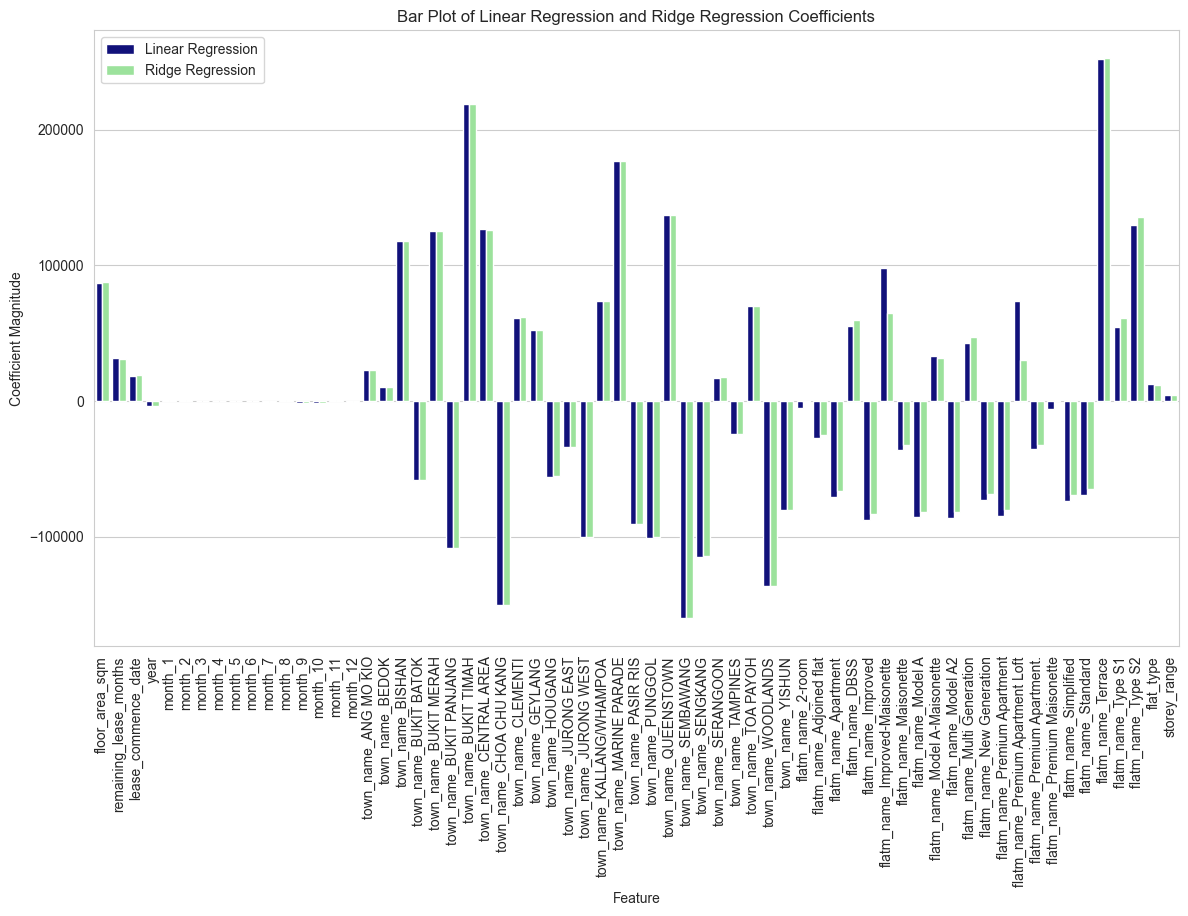

In [23]:
# Extract the coefficients of the linear regression model. 
lr_coefs = lr_pipeline.named_steps['regressor'].coef_

# Extract the oefficients of the ridge regression model. 
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_

# Assurming feature_names contains the names of the features after preprocessing.
feature_names = (
    numerical_features +
    list(ridge_pipeline.named_steps['preprocessor'].transformers_[1]
[1].get_feature_names_out(nominal_features)) + 
    ordinal_features + 
    passthrough_features
)

# Create a DataFrame for plotting.
coef_df = pd.DataFrame({ 
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Ridge Regression': ridge_coefs 
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn. 
plt.figure(figsize=(14,8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'lightgreen'])
plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Ridge Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True,axis='y')
plt.legend(loc='upper left')
plt.show()

In [26]:
from sklearn.linear_model import Lasso

# Fit Lasso Regression with default alpha
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1, 
                        max_iter=5000,       # ← Increase this (try 2000 → 10000)
                        tol=1e-4))             # ← Optional: slightly looser tolerance
])
lasso_pipeline.fit(X_train, y_train)

# Predict on the validation set with Lasso Regression
y_val_pred_lasso = lasso_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Lasso Regression
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = mean_squared_error(y_val, y_val_pred_lasso)**0.5  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

# Display the metrics for Lasso Regression
print("Lasso Regression Metrics:")
print(f"Lasso Validation MAE: {val_mae_lasso}")
print(f"Lasso Validation MSE: {val_mse_lasso}")
print(f"Lasso Validation RMSE: {val_rmse_lasso}")
print(f"Lasso Validation R²: {val_r2_lasso}")

Lasso Regression Metrics:
Lasso Validation MAE: 41337.574423757505
Lasso Validation MSE: 2907774468.0553145
Lasso Validation RMSE: 53923.78388109754
Lasso Validation R²: 0.8661238481191874


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 442810875577.90625, tolerance: 152653550778.20486
  model = cd_fast.sparse_enet_coordinate_descent(


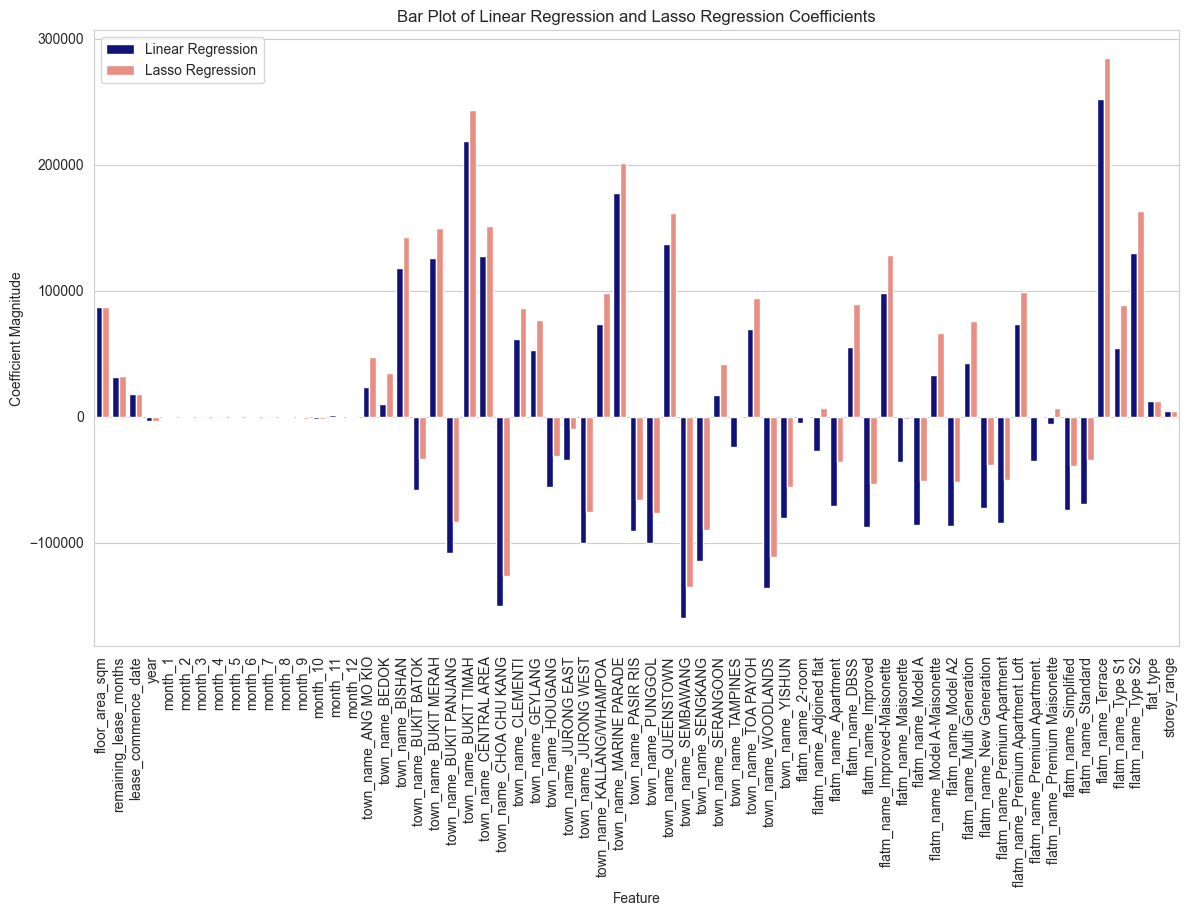

In [27]:
# Extract the coefficients of the linear and lasso regression models
lr_coefs = lr_pipeline.named_steps['regressor'].coef_
lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_

# Extract feature names after preprocessing
feature_names = (
    numerical_features +
    list(preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)) +
    ordinal_features +
    passthrough_features
)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Lasso Regression': lasso_coefs
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn
plt.figure(figsize=(14, 8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'salmon'])

plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Lasso Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.legend(loc='upper left')
plt.show()

In [32]:
from sklearn.linear_model import ElasticNet

# Fit ElasticNet Regression with default alpha
enet_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(alpha=1, 
                             l1_ratio=0.99,  # Balance between Lasso and Ridge (0.5 means equal weight)
                            max_iter=5000,       # ← Increase this (try 2000 → 10000)
                        tol=1e-4))             # ← Optional: slightly looser tolerance
])
enet_pipeline.fit(X_train, y_train)

# Predict on the validation set with ElasticNet Regression
y_val_pred_enet = enet_pipeline.predict(X_val)

# Calculate regression metrics for validation set with ElasticNet Regression
val_mae_enet = mean_absolute_error(y_val, y_val_pred_enet)
val_mse_enet = mean_squared_error(y_val, y_val_pred_enet)
val_rmse_enet = mean_squared_error(y_val, y_val_pred_enet)**0.5  # RMSE is the square root of MSE
val_r2_enet = r2_score(y_val, y_val_pred_enet)

# Display the metrics for ElasticNet Regression
print("ElasticNet Regression Metrics:")
print(f"ElasticNet Validation MAE: {val_mae_enet}")
print(f"ElasticNet Validation MSE: {val_mse_enet}")
print(f"ElasticNet Validation RMSE: {val_rmse_enet}")
print(f"ElasticNet Validation R²: {val_r2_enet}")

ElasticNet Regression Metrics:
ElasticNet Validation MAE: 44921.26686879227
ElasticNet Validation MSE: 3657507820.026634
ElasticNet Validation RMSE: 60477.333109410785
ElasticNet Validation R²: 0.8316055533885268


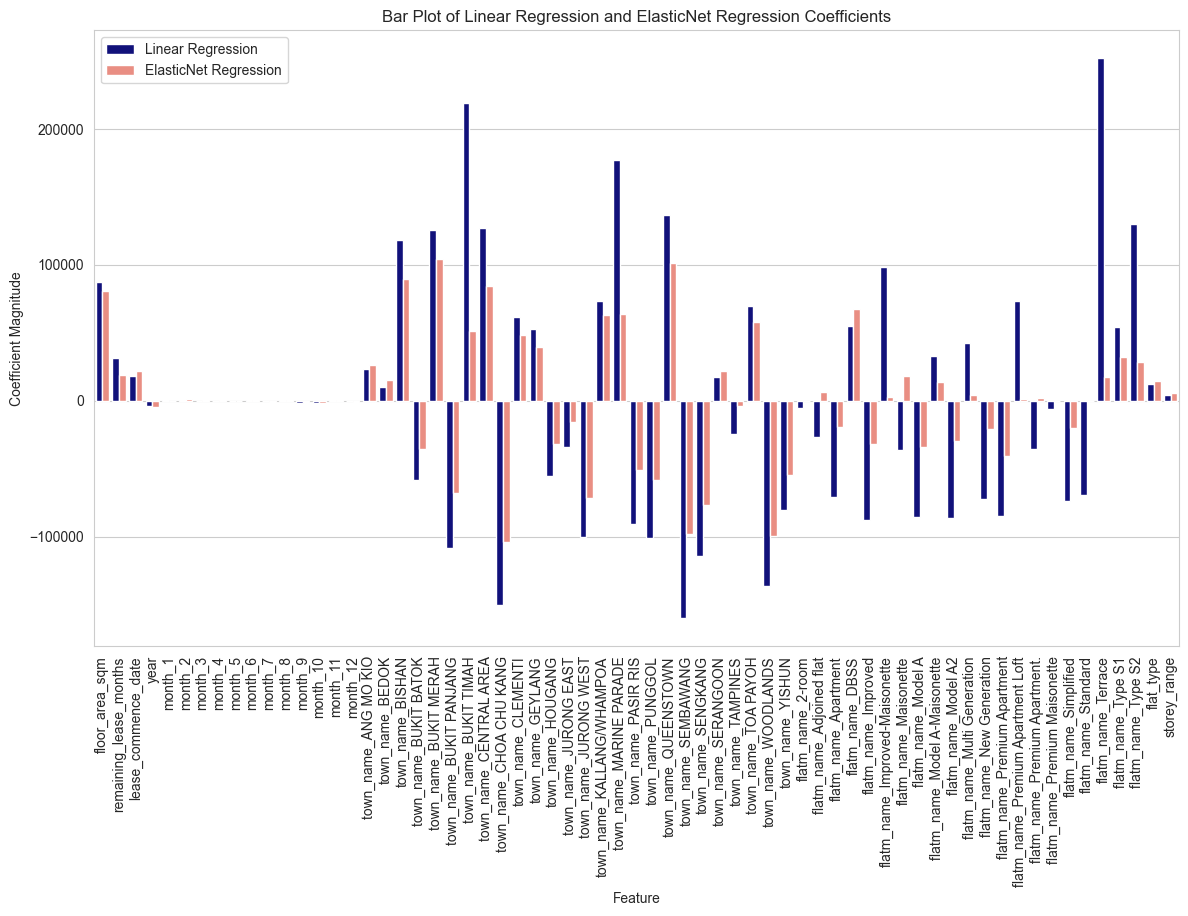

In [33]:
# Extract the coefficients of the linear and elastic net regression models
lr_coefs = lr_pipeline.named_steps['regressor'].coef_
enet_coefs = enet_pipeline.named_steps['regressor'].coef_

# Extract feature names after preprocessing
feature_names = (
    numerical_features +
    list(preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)) +
    ordinal_features +
    passthrough_features
)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'ElasticNet Regression': enet_coefs
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn
plt.figure(figsize=(14, 8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'salmon'])

plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and ElasticNet Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.legend(loc='upper left')
plt.show()

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform grid search with cross-validation for Ridge regression
ridge_grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_grid_search.fit(X_train, y_train)

# Perform grid search with cross-validation for Lasso regression
lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train, y_train)

# Print the best parameters found by grid search for Ridge regression
print("Best Ridge parameters:", ridge_grid_search.best_params_)

# Print the best parameters found by grid search for Lasso regression
print("Best Lasso parameters:", lasso_grid_search.best_params_)


Best Ridge parameters: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}
Best Lasso parameters: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 101722079994931.4, tolerance: 152653550778.20486
  model = cd_fast.sparse_enet_coordinate_descent(


In [35]:
# Evaluate the best Ridge model on the validation set
best_ridge_model = ridge_grid_search.best_estimator_
y_val_pred_ridge = best_ridge_model.predict(X_val)

# Calculate regression metrics for validation set for Ridge
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = mean_absolute_error(y_val, y_val_pred_ridge)**0.5  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("Best Ridge Regression Metrics:")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R²: {val_r2_ridge}")

# Evaluate the best Lasso model on the validation set
best_lasso_model = lasso_grid_search.best_estimator_
y_val_pred_lasso = best_lasso_model.predict(X_val)

# Calculate regression metrics for validation set for Lasso
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = mean_absolute_error(y_val, y_val_pred_lasso)**0.5  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("Best Lasso Regression Metrics:")
print(f"Lasso Validation MAE: {val_mae_lasso}")
print(f"Lasso Validation MSE: {val_mse_lasso}")
print(f"Lasso Validation RMSE: {val_rmse_lasso}")
print(f"Lasso Validation R²: {val_r2_lasso}")

Best Ridge Regression Metrics:
Ridge Validation MAE: 41338.43055897643
Ridge Validation MSE: 2908645879.2877393
Ridge Validation RMSE: 203.31854455257258
Ridge Validation R²: 0.8660837276821368
Best Lasso Regression Metrics:
Lasso Validation MAE: 41338.1066549401
Lasso Validation MSE: 2907439398.6556225
Lasso Validation RMSE: 203.31774800774303
Lasso Validation R²: 0.8661392749696315


In [36]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions for hyperparameter tuning
param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform randomized search with cross-validation for Ridge regression
ridge_random_search = RandomizedSearchCV(ridge_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
ridge_random_search.fit(X_train, y_train)

# Perform randomized search with cross-validation for Lasso regression
lasso_random_search = RandomizedSearchCV(lasso_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
lasso_random_search.fit(X_train, y_train)

# Print the best parameters found by random search for Ridge regression
print("Best Ridge parameters:", ridge_random_search.best_params_)

# Print the best parameters found by random search for Lasso regression
print("Best Lasso parameters:", lasso_random_search.best_params_)

# Best model from Ridge regression (Grid Search)
best_ridge_model = ridge_grid_search.best_estimator_

# Predict on the test set with Ridge Regression
y_test_pred_ridge = best_ridge_model.predict(X_test)

# Calculate regression metrics for the test set for Ridge
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
test_rmse_ridge = mean_absolute_error(y_test, y_test_pred_ridge)**0.5
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print("Best Ridge Regression Model, Final Test Metrics:")
print(f"Final Test MAE: {test_mae_ridge}")
print(f"Final Test MSE: {test_mse_ridge}")
print(f"Final Test RMSE: {test_rmse_ridge}")
print(f"Final Test R²: {test_r2_ridge}")

Best Ridge parameters: {'regressor__fit_intercept': True, 'regressor__alpha': 0.1}
Best Lasso parameters: {'regressor__fit_intercept': True, 'regressor__alpha': 0.1}
Best Ridge Regression Model, Final Test Metrics:
Final Test MAE: 42015.85955778123
Final Test MSE: 3033795343.261973
Final Test RMSE: 204.97770502613506
Final Test R²: 0.8573536686406436


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:592: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 101722079994931.4, tolerance: 152653550778.20486
  model = cd_fast.sparse_enet_coordinate_descent(
